# Yahoo Finance — daily asset performance

Configure assets below, then run top to bottom. Adjusted daily closes account for splits/dividends where Yahoo provides them. Indices, futures and ETFs represent different instruments, in their quoted currencies.

Only jointly observed dates enter the comparison; no forward filling. Bitcoin weekend moves are included in the next common-date return, never counted as separate observations. All sampled returns use the same 252-observation annualization convention. Leverage resets on **every observed underlying session before sampling common dates**, including sessions excluded by another market's calendar.

Synthetic products isolate daily-reset leverage, compounding and volatility drag. They exclude financing/borrowing costs, management fees/expense ratios, tracking error, transaction costs, taxes, realistic ETF implementation constraints and intraday rebalancing effects.

Dependencies: `pip install yfinance matplotlib scipy` in the notebook kernel environment. Download API: [yfinance documentation](https://ranaroussi.github.io/yfinance/reference/api/yfinance.download.html).

## 1. Imports and configuration

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from IPython.display import display
from scipy.optimize import minimize

assets = {
    "Apple": "AAPL",
    "Nasdaq 100": "^NDX",
    "S&P 500": "^GSPC",
    "Dow Jones": "^DJI",
    "CAC 40": "^FCHI",
    "Gold": "GC=F",
    # "MSCI World ETF": "IWDA.AS",
    # "Bitcoin": "BTC-USD",
}
leveraged_assets = {
    "Apple": 1.5,
    "Nasdaq 100": 2.0,
}
include_leveraged_in_frontier = True  # Replace each configured underlying when True.
frontier_points = 50
portfolio_targets = {
    "Prudent": 0.15,
    "Modéré": 0.20,
    "Dynamique": 0.30,
    "Agressif": 0.40,
    "Très agressif": 0.50,
}
allocation_display_threshold = 0.01  # Display only; full numeric weights are retained.
portfolio_tolerance = 1e-7
trading_days = 252
risk_free_rate = 0.00  # Annual rate: Sharpe = (annual mean - rate) / annual volatility.
initial_nav = 100.0
calendar_days_per_year = 365.25

if not assets or len(set(assets.values())) != len(assets):
    raise ValueError("Configure at least one asset, with distinct tickers.")
if trading_days <= 0 or not np.isfinite(risk_free_rate):
    raise ValueError("Invalid annualization or risk-free rate.")
def format_leverage(leverage):
    """One source of truth for leverage labels; no unnecessary trailing zeros."""
    return np.format_float_positional(float(leverage), trim="-")


def leveraged_name(underlying, leverage):
    return f"{underlying} x{format_leverage(leverage)}"


if not isinstance(include_leveraged_in_frontier, bool):
    raise ValueError("include_leveraged_in_frontier must be boolean.")
if not isinstance(frontier_points, int) or frontier_points < 2:
    raise ValueError("frontier_points must be an integer of at least two.")
for underlying, leverage in leveraged_assets.items():
    if (underlying not in assets or not np.isfinite(leverage) or leverage <= 0
            or leveraged_name(underlying, leverage) in assets):
        raise ValueError(f"Invalid leverage configuration for {underlying}.")
leveraged_labels = {
    underlying: leveraged_name(underlying, leverage)
    for underlying, leverage in leveraged_assets.items()
}
if len(set(leveraged_labels.values())) != len(leveraged_labels):
    raise ValueError("Leveraged asset labels must be unique.")

## 2. Download and common study dates

In [2]:
def prepare_common_prices(history):
    """Find overlapping availability, then retain only jointly observed dates."""
    if history.empty or not history.index.is_monotonic_increasing or not history.index.is_unique:
        raise ValueError("History must be nonempty, sorted and have unique dates.")
    availability = pd.DataFrame({
        "Start date": history.apply(pd.Series.first_valid_index),
        "End date": history.apply(pd.Series.last_valid_index),
        "Observations": history.count(),
    }).rename_axis("Asset")
    missing = availability.index[availability["Observations"].eq(0)].tolist()
    if missing:
        raise ValueError(f"No Yahoo history for configured assets: {missing}")
    if np.isinf(history.to_numpy()).any() or (history <= 0).any().any():
        raise ValueError("Observed base prices must be finite and strictly positive.")
    start = availability["Start date"].max()
    end = availability["End date"].min()
    common = history.loc[start:end].dropna(how="any")
    if len(common) < 3:
        raise ValueError("At least three common observations are required.")
    return common, availability

# Explicit adjustment avoids dependence on yfinance defaults.
raw = yf.download(
    list(assets.values()), period="max", interval="1d", auto_adjust=True,
    group_by="column", multi_level_index=True, ignore_tz=True,
    keepna=True, progress=False, threads=False, timeout=30,
)
if raw is None or raw.empty:
    raise RuntimeError("Yahoo returned no data. Check connectivity and tickers.")
history = raw["Close"].reindex(columns=list(assets.values()))
history = history.rename(columns={ticker: name for name, ticker in assets.items()}).sort_index()
base_prices, availability = prepare_common_prices(history)
study_period = (base_prices.index[0], base_prices.index[-1])
print(f"Common study period: {study_period[0]:%Y-%m-%d} → {study_period[1]:%Y-%m-%d}")
print(f"{len(base_prices):,} common observations; no prices forward-filled.")
display(availability.style.format({
    "Start date": lambda value: value.strftime("%Y-%m-%d"),
    "End date": lambda value: value.strftime("%Y-%m-%d"),
}).set_caption("Downloaded history availability (before common-date filtering)"))

Common study period: 2000-08-30 → 2026-10-02
6,476 common observations; no prices forward-filled.


,Start date,End date,Observations
Asset,,,
Apple,1980-12-12,2026-10-02,11544
Nasdaq 100,1985-10-01,2026-10-02,10331
S&P 500,1927-12-30,2026-10-02,24806
Dow Jones,1992-01-02,2026-10-02,8750
CAC 40,1990-03-01,2026-10-02,9294
Gold,2000-08-30,2026-10-02,6548


## 3. Synthetic daily-reset leveraged assets

In [3]:
def build_daily_leveraged_series(underlying_prices, leverage, starting_nav=100.0):
    """Compound leveraged close-to-close returns; zero NAV is absorbing."""
    if (underlying_prices.empty or not underlying_prices.index.is_unique
            or not underlying_prices.index.is_monotonic_increasing):
        raise ValueError("Underlying must have a nonempty, unique, sorted index.")
    if not np.isfinite(underlying_prices.to_numpy()).all() or (underlying_prices <= 0).any():
        raise ValueError("Underlying prices must be finite, positive and without missing values.")
    if not np.isfinite(leverage) or leverage <= 0 or not np.isfinite(starting_nav) or starting_nav <= 0:
        raise ValueError("Leverage and starting NAV must be finite and positive.")
    underlying_returns = underlying_prices.pct_change(fill_method=None)
    growth = (1 + leverage * underlying_returns).clip(lower=0)
    growth.iloc[0] = 1.0
    nav = starting_nav * growth.cumprod()
    nav = nav.mask(growth.eq(0).cummax(), 0.0)
    if not np.isfinite(nav.to_numpy()).all():
        raise ValueError("Synthetic NAV overflowed; reduce leverage or study duration.")
    return nav

prices = base_prices.copy()
leveraged_diagnostics = []
for underlying, leverage in leveraged_assets.items():
    name = leveraged_labels[underlying]
    # Preserve all actual underlying sessions inside the study period.
    underlying_prices = history[underlying].loc[study_period[0]:study_period[1]].dropna()
    nav = build_daily_leveraged_series(underlying_prices, leverage, initial_nav)
    prices[name] = nav.reindex(base_prices.index)
    underlying_returns = underlying_prices.pct_change(fill_method=None).iloc[1:]
    theoretical_returns = leverage * underlying_returns
    wipeout_dates = nav.index[nav.eq(0)]
    leveraged_diagnostics.append({
        "Leveraged asset": name,
        "Underlying": underlying,
        "Leverage": leverage,
        "Worst underlying daily return": underlying_returns.min(),
        "Worst theoretical leveraged return": theoretical_returns.min(),
        "Wipeout occurred": len(wipeout_dates) > 0,
        "Wipeout date": wipeout_dates[0] if len(wipeout_dates) else pd.NaT,
    })
    assert nav.index.equals(underlying_prices.index)
    # Sampled multi-session returns need not equal leverage * base interval returns.
    alive = nav.shift(1).gt(0) & theoretical_returns.reindex(nav.index).gt(-1)
    np.testing.assert_allclose(
        nav.pct_change(fill_method=None).loc[alive],
        (leverage * underlying_prices.pct_change(fill_method=None)).loc[alive],
        rtol=1e-10, atol=1e-12,
    )
    if len(wipeout_dates):
        assert nav.loc[wipeout_dates[0]:].eq(0).all()

leveraged_diagnostics = pd.DataFrame(leveraged_diagnostics, columns=[
    "Leveraged asset", "Underlying", "Leverage", "Worst underlying daily return",
    "Worst theoretical leveraged return", "Wipeout occurred", "Wipeout date",
]).set_index("Leveraged asset")

## 4. Validation and performance calculations

In [4]:
# Small deterministic regression paths, independent of the configured assets.
validation_checks = []
example = pd.Series([100.0, 110.0, 99.0], index=pd.date_range("2020-01-01", periods=3))
for test_leverage in (1.3, 1.5, 2.0, 3.0, 4.0):
    expected = initial_nav * np.r_[1.0, np.cumprod(1 + test_leverage * np.array([0.1, -0.1]))]
    np.testing.assert_allclose(build_daily_leveraged_series(example, test_leverage, initial_nav), expected)
    for underlying in ("Apple", "Nasdaq 100"):
        assert leveraged_name(underlying, test_leverage) == f"{underlying} x{test_leverage:g}"
    validation_checks.append(f"Synthetic returns and labels at leverage {test_leverage:g}")
for test_leverage in (1.5, 2.0, 4.0):
    for loss in (1 / test_leverage, min(1 / test_leverage + 0.1, 0.99)):
        bankruptcy_example = pd.Series([100.0, 100 * (1 - loss), 100.0, 200.0])
        np.testing.assert_allclose(
            build_daily_leveraged_series(bankruptcy_example, test_leverage), [100, 0, 0, 0], atol=1e-12,
        )
validation_checks.append("Exact-threshold/beyond-threshold wipeout stays zero")
np.testing.assert_allclose(
    build_daily_leveraged_series(example.iloc[:2], 1.5),
    build_daily_leveraged_series(example, 1.5).iloc[:2],
)
validation_checks.append("No lookahead")
# An unrelated market misses the middle session: compound BEFORE alignment.
alignment_path = build_daily_leveraged_series(example, 1.5).iloc[[0, 2]]
np.testing.assert_allclose(alignment_path, [100, 97.75])
validation_checks.append("Every underlying session compounded before alignment")
assert prices.index.equals(base_prices.index)
assert prices.notna().all().all() and np.isfinite(prices.to_numpy()).all()
assert (prices >= 0).all().all() and (prices.iloc[0] > 0).all()
assert list(prices.columns) == list(assets) + list(leveraged_labels.values())

validation_checks.append("Aligned prices and configured labels without stale names")


def compute_performance(prices, trading_days=252, risk_free_rate=0.00, calendar_days_per_year=365.25):
    """One numeric pipeline for observed prices and synthetic NAVs."""
    if len(prices) < 3 or not prices.index.is_unique or not prices.index.is_monotonic_increasing:
        raise ValueError("At least three chronologically sorted common dates are required.")
    if (not np.isfinite(prices.to_numpy()).all() or (prices < 0).any().any()
            or (prices.iloc[0] <= 0).any()):
        raise ValueError("Prices must be finite, nonnegative and initially positive.")
    if ((prices.shift(1) == 0) & (prices != 0)).any().any():
        raise ValueError("A wiped-out series must stay at zero.")
    elapsed_years = (prices.index[-1] - prices.index[0]).days / calendar_days_per_year
    if elapsed_years <= 0 or trading_days <= 0 or not np.isfinite(risk_free_rate):
        raise ValueError("Invalid study duration or annualization settings.")
    # Wipeout returns -100%; subsequent zero/zero intervals count as 0%.
    returns = prices.pct_change(fill_method=None).mask(prices.shift(1).eq(0), 0.0).iloc[1:]
    cagr = (prices.iloc[-1] / prices.iloc[0]) ** (1 / elapsed_years) - 1
    annual_mean_return = returns.mean() * trading_days
    annual_volatility = returns.std(ddof=1) * np.sqrt(trading_days)
    drawdown = prices / prices.cummax() - 1
    max_drawdown = drawdown.min()
    sharpe = (annual_mean_return - risk_free_rate) / annual_volatility.replace(0, np.nan)
    calmar = cagr / max_drawdown.abs().replace(0, np.nan)
    return pd.DataFrame({
        "CAGR": cagr,
        "Mean return annualized": annual_mean_return,
        "Volatility annualized": annual_volatility,
        "Max Drawdown": max_drawdown,
        "Sharpe": sharpe,
        "Calmar": calmar,
    }).rename_axis("Asset").sort_values("Calmar", ascending=False)

stats = compute_performance(prices, trading_days, risk_free_rate, calendar_days_per_year)
# Adding synthetic assets must never alter the base-asset metrics.
pd.testing.assert_frame_equal(
    stats.loc[list(assets)],
    compute_performance(base_prices, trading_days, risk_free_rate, calendar_days_per_year).loc[list(assets)],
)
validation_checks.append("Base-asset statistics unchanged")
print(f"{len(validation_checks)} leverage/performance validation checks passed.")

10 leverage/performance validation checks passed.


## 5. Study coverage, diagnostics and results

In [5]:
study_coverage = pd.DataFrame({
    "Start date": prices.apply(pd.Series.first_valid_index),
    "End date": prices.apply(pd.Series.last_valid_index),
    "Observations": prices.count(),
}).rename_axis("Asset")
display(study_coverage.style.format({
    "Start date": lambda value: value.strftime("%Y-%m-%d"),
    "End date": lambda value: value.strftime("%Y-%m-%d"),
}).set_caption("Actual common study dates — all compared assets"))

if not leveraged_diagnostics.empty:
    display(leveraged_diagnostics.style.format({
        "Leverage": format_leverage,
        "Worst underlying daily return": "{:.2%}",
        "Worst theoretical leveraged return": "{:.2%}",
        "Wipeout date": lambda value: "—" if pd.isna(value) else value.strftime("%Y-%m-%d"),
    }).set_caption("Daily-reset leverage diagnostics (every underlying session in the study)"))

percentage_metrics = ["CAGR", "Mean return annualized", "Volatility annualized", "Max Drawdown"]
display(stats.style.format({
    **{column: "{:.2%}" for column in percentage_metrics},
    "Sharpe": "{:.2f}", "Calmar": "{:.2f}",
}, na_rep="—").set_caption("Performance — Calmar descending; undefined ratios shown as —"))

,Start date,End date,Observations
Asset,,,
Apple,2000-08-30,2026-10-02,6476
Nasdaq 100,2000-08-30,2026-10-02,6476
S&P 500,2000-08-30,2026-10-02,6476
Dow Jones,2000-08-30,2026-10-02,6476
CAC 40,2000-08-30,2026-10-02,6476
Gold,2000-08-30,2026-10-02,6476
Apple x1.5,2000-08-30,2026-10-02,6476
Nasdaq 100 x2,2000-08-30,2026-10-02,6476


,Underlying,Leverage,Worst underlying daily return,Worst theoretical leveraged return,Wipeout occurred,Wipeout date
Leveraged asset,,,,,,
Apple x1.5,Apple,1.5,-51.87%,-77.80%,False,—
Nasdaq 100 x2,Nasdaq 100,2,-12.19%,-24.39%,False,—


,CAGR,Mean return annualized,Volatility annualized,Max Drawdown,Sharpe,Calmar
Asset,,,,,,
Apple x1.5,31.94%,45.52%,56.00%,-95.43%,0.81,0.33
Apple,25.51%,30.35%,37.34%,-79.32%,0.81,0.32
Gold,10.99%,12.22%,18.00%,-44.36%,0.68,0.25
S&P 500,6.48%,8.23%,19.24%,-56.78%,0.43,0.11
Dow Jones,6.03%,7.62%,18.27%,-53.78%,0.42,0.11
Nasdaq 100,8.17%,11.41%,26.23%,-80.37%,0.43,0.10
Nasdaq 100 x2,9.33%,22.78%,52.45%,-97.83%,0.43,0.10
CAC 40,0.67%,3.08%,21.89%,-64.95%,0.14,0.01


## 6. Long-only historical portfolio efficient frontier

The universe contains one version of each underlying. With `include_leveraged_in_frontier=True`, configured synthetic assets **replace** their base assets. Other assets stay in the universe; all individual points remain on the chart.

Weights are constant and rebalanced at each common observation. Portfolio CAGR compounds the weighted **return series** over the same calendar study period as individual assets. Covariance accounts for correlations; all sampled returns retain the notebook's 252-observation convention.

SLSQP maximizes mean log growth under a volatility **ceiling**, nonnegative weights and weights summing to one. Mean log growth is concave and the risk constraint is convex, so this traces the upper efficient branch from minimum volatility to maximum historical growth. Risk above the maximum-growth portfolio adds no achievable CAGR. The table shows the minimum-volatility and conventional maximum-Sharpe portfolios; Sharpe uses arithmetic mean excess return. Optimization is historical and excludes portfolio trading costs.

Both universe modes are printed explicitly below. Single-asset portfolios are checked against standalone statistics, and the frontier is checked at each allowed asset's exact volatility. The last of the 50 risk ceilings uses the maximum-growth portfolio of the selected universe; its CAGR must reach or exceed every allowed single-asset CAGR.


In [6]:
# Keep the aligned returns and covariance available for further analysis.
returns = prices.pct_change(fill_method=None).mask(prices.shift(1).eq(0), 0.0).iloc[1:]
cov_matrix = returns.cov() * trading_days
corr_matrix = returns.corr()
elapsed_years = (prices.index[-1] - prices.index[0]).days / calendar_days_per_year


def select_frontier_assets(use_leveraged):
    return [leveraged_labels.get(asset, asset) if use_leveraged else asset for asset in assets]


# Display both modes independently of the configured optimization mode.
for use_leveraged in (False, True):
    selected = select_frontier_assets(use_leveraged)
    print(f"frontier_assets (include_leveraged_in_frontier={use_leveraged}): {selected}")
    assert len(selected) == len(set(selected)) == len(assets)
    for underlying, label in leveraged_labels.items():
        assert not (underlying in selected and label in selected)
        assert (label in selected) == use_leveraged
        assert (underlying in selected) != use_leveraged

frontier_assets = select_frontier_assets(include_leveraged_in_frontier)
frontier_returns = returns[frontier_assets]
frontier_cov_matrix = frontier_returns.cov() * trading_days
assert frontier_returns.columns.tolist() == frontier_assets
assert frontier_cov_matrix.index.tolist() == frontier_assets
assert frontier_cov_matrix.columns.tolist() == frontier_assets
np.testing.assert_allclose(
    frontier_cov_matrix, cov_matrix.loc[frontier_assets, frontier_assets], atol=1e-12,
)
validation_checks.append("Frontier returns and covariance use exactly the selected universe")
R = frontier_returns.to_numpy()
Sigma = frontier_cov_matrix.to_numpy()
mu = R.mean(axis=0) * trading_days
n_assets = len(frontier_assets)
equal_weights = np.full(n_assets, 1 / n_assets)
variance_scale = max(float(np.diag(Sigma).max()), 1e-12)
bounds = [(0.0, 1.0)] * n_assets
budget = {"type": "eq", "fun": lambda w: w.sum() - 1,
          "jac": lambda w: np.ones(n_assets)}


def variance(w):
    return float(w @ Sigma @ w)


def negative_log_growth(w):
    # A zero growth factor is a historical wipeout. The tiny floor only keeps
    # optimizer evaluations finite at simplex boundaries; reported CAGR is exact.
    growth = np.maximum(1 + R @ w, np.finfo(float).tiny)
    return -float(np.log(growth).mean()) * trading_days


def negative_log_growth_gradient(w):
    growth = np.maximum(1 + R @ w, np.finfo(float).tiny)
    return -(R.T @ (1 / growth)) * trading_days / len(R)


def solve_portfolio(objective, gradient, start, extra_constraints=()):
    result = minimize(
        objective, start, jac=gradient, method="SLSQP", bounds=bounds,
        constraints=[budget, *extra_constraints],
        options={"ftol": 1e-10, "maxiter": 1000},
    )
    if not result.success:
        # Retry from the attained point with a practical numerical tolerance.
        result = minimize(
            objective, result.x, jac=gradient, method="SLSQP", bounds=bounds,
            constraints=[budget, *extra_constraints],
            options={"ftol": 1e-7, "maxiter": 1000},
        )
    if not result.success:
        raise RuntimeError(f"Portfolio optimization failed: {result.message}")
    # Validate the actual solver output before numerical cleanup.
    assert np.isfinite(result.x).all()
    assert (result.x >= -1e-8).all() and (result.x <= 1 + 1e-8).all()
    np.testing.assert_allclose(result.x.sum(), 1, rtol=0, atol=1e-8)
    w = np.clip(result.x, 0, 1)
    w /= w.sum()
    if abs(w.sum() - 1) > 1e-8 or (w < 0).any():
        raise RuntimeError("Optimizer produced infeasible portfolio weights.")
    return w


def portfolio_metrics(w):
    portfolio_returns = R @ w
    growth = 1 + portfolio_returns
    cagr = -1.0 if (growth <= 0).any() else float(np.expm1(np.log(growth).sum() / elapsed_years))
    volatility = np.sqrt(max(variance(w), 0))
    series_volatility = portfolio_returns.std(ddof=1) * np.sqrt(trading_days)
    np.testing.assert_allclose(volatility, series_volatility, rtol=1e-9, atol=1e-12)
    annual_mean = float(mu @ w)
    return {
        "CAGR": cagr,
        "Mean return annualized": annual_mean,
        "Volatility": volatility,
        "Sharpe": (annual_mean - risk_free_rate) / volatility if volatility > 0 else np.nan,
        "weights": pd.Series(w, index=frontier_assets, name="Weight"),
    }


minimum_weights = solve_portfolio(
    lambda w: variance(w) / variance_scale,
    lambda w: 2 * Sigma @ w / variance_scale,
    equal_weights,
)
minimum_volatility_portfolio = portfolio_metrics(minimum_weights)
maximum_growth_weights = solve_portfolio(
    negative_log_growth, negative_log_growth_gradient, equal_weights,
)
maximum_growth_portfolio = portfolio_metrics(maximum_growth_weights)


def negative_sharpe(w):
    vol = np.sqrt(max(variance(w), 1e-24))
    return -float((mu @ w - risk_free_rate) / vol)


def negative_sharpe_gradient(w):
    vol = np.sqrt(max(variance(w), 1e-24))
    excess = mu @ w - risk_free_rate
    return -mu / vol + excess * (Sigma @ w) / vol ** 3


# Deterministic starts also cover universes with nonpositive excess returns,
# where the Sharpe objective need not be globally quasiconcave.
sharpe_candidates = [
    solve_portfolio(negative_sharpe, negative_sharpe_gradient, start)
    for start in [equal_weights, minimum_weights, maximum_growth_weights, *np.eye(n_assets)]
]
maximum_sharpe_weights = min(sharpe_candidates, key=negative_sharpe)
maximum_sharpe_portfolio = portfolio_metrics(maximum_sharpe_weights)

risk_targets = np.linspace(
    minimum_volatility_portfolio["Volatility"], maximum_growth_portfolio["Volatility"], frontier_points,
)
frontier_rows = []
warm_start = minimum_weights
for position, target in enumerate(risk_targets):
    if position == 0:
        weights = minimum_weights
    elif position == len(risk_targets) - 1:
        weights = maximum_growth_weights
    else:
        scale = max(target ** 2, 1e-12)
        risk_ceiling = {
            "type": "ineq",
            "fun": lambda w, t=target, s=scale: (t ** 2 - variance(w)) / s,
            "jac": lambda w, s=scale: -2 * Sigma @ w / s,
        }
        weights = solve_portfolio(
            negative_log_growth, negative_log_growth_gradient, warm_start, [risk_ceiling],
        )
    metrics = portfolio_metrics(weights)
    if metrics["Volatility"] > target + 1e-7:
        raise RuntimeError("A frontier portfolio exceeds its volatility ceiling.")
    frontier_rows.append({"Risk ceiling": target, **metrics})
    warm_start = weights
frontier = pd.DataFrame(frontier_rows)
# Collapse repeated endpoints for degenerate universes instead of drawing a lower branch.
efficient_frontier = frontier.drop_duplicates(subset=["Volatility", "CAGR"]).copy()

validation_checks.append("Both frontier modes select one version of each underlying")
all_portfolios = [minimum_volatility_portfolio, maximum_growth_portfolio, maximum_sharpe_portfolio, *frontier_rows]
for portfolio in all_portfolios:
    weights = portfolio["weights"].to_numpy()
    np.testing.assert_allclose(weights.sum(), 1, atol=1e-8)
    assert (weights >= 0).all() and (weights <= 1).all()
validation_checks.append("All optimized weights sum to one")
validation_checks.append("All optimized portfolios are long-only without borrowing")
validation_checks.append("Covariance and return-series volatility agree for every portfolio")
assert (frontier["Volatility"] <= frontier["Risk ceiling"] + 1e-7).all()
validation_checks.append("All frontier risk ceilings satisfied")
assert (np.diff(frontier["CAGR"]) >= -1e-7).all()
assert (np.diff(frontier["Volatility"]) >= -1e-7).all()
validation_checks.append("Upper efficient branch has nondecreasing risk and CAGR")
single_asset_rows = []
for asset in frontier_assets:
    weights = np.eye(n_assets)[frontier_assets.index(asset)]
    np.testing.assert_allclose(weights.sum(), 1, rtol=0, atol=1e-12)
    assert (weights >= 0).all()
    metrics = portfolio_metrics(weights)
    np.testing.assert_allclose(metrics["CAGR"], stats.loc[asset, "CAGR"], atol=1e-10)
    np.testing.assert_allclose(metrics["Volatility"], stats.loc[asset, "Volatility annualized"], atol=1e-12)
    single_asset_rows.append({"Asset": asset, **metrics})
single_asset_portfolios = pd.DataFrame(single_asset_rows).set_index("Asset")
validation_checks.append("Every 100% asset portfolio is feasible and matches standalone CAGR/volatility")

# This implementation targets risk ceilings, not arithmetic return targets.
# Maximum historical log growth must cover every feasible single-asset CAGR.
maximum_frontier_cagr = float(frontier["CAGR"].max())
maximum_single_asset_cagr = float(single_asset_portfolios["CAGR"].max())
assert maximum_frontier_cagr >= maximum_single_asset_cagr - 1e-7
np.testing.assert_allclose(frontier.iloc[-1]["CAGR"], maximum_growth_portfolio["CAGR"], atol=1e-10)
validation_checks.append("Frontier endpoint reaches or exceeds every allowed single-asset CAGR")

# Check the frontier at each exact asset risk; the 50 plotted samples may not
# include that risk. Each vertex provides a feasible start for its own ceiling.
dominance_rows = []
for asset, single in single_asset_portfolios.iterrows():
    target = single["Volatility"]
    if maximum_growth_portfolio["Volatility"] <= target + 1e-10:
        metrics = maximum_growth_portfolio
    else:
        scale = max(target ** 2, 1e-12)
        ceiling = {
            "type": "ineq",
            "fun": lambda w, t=target, s=scale: (t ** 2 - variance(w)) / s,
            "jac": lambda w, s=scale: -2 * Sigma @ w / s,
        }
        weights = solve_portfolio(
            negative_log_growth, negative_log_growth_gradient,
            single["weights"].to_numpy(), [ceiling],
        )
        metrics = portfolio_metrics(weights)
    assert metrics["Volatility"] <= target + 1e-7
    assert metrics["CAGR"] >= single["CAGR"] - 1e-7
    all_portfolios.append(metrics)
    dominance_rows.append({
        "Asset": asset, "100% asset CAGR": single["CAGR"],
        "100% asset volatility": target, "Frontier CAGR at asset risk": metrics["CAGR"],
        "Frontier volatility": metrics["Volatility"],
    })
frontier_asset_validation = pd.DataFrame(dominance_rows).set_index("Asset")
validation_checks.append("Frontier reaches or dominates every allowed asset at its own risk")
for portfolio in all_portfolios:
    assert portfolio["weights"].index.tolist() == frontier_assets
    w = portfolio["weights"].to_numpy()
    np.testing.assert_allclose(w.sum(), 1, rtol=0, atol=1e-8)
    assert (w >= -1e-8).all() and (w <= 1 + 1e-8).all()
validation_checks.append("All weights and labels match the actual optimization series")
display(frontier_asset_validation.style.format("{:.2%}").set_caption(
    "100% asset feasibility and frontier dominance (selected optimization universe)"
))
for portfolio in all_portfolios:
    w = portfolio["weights"].to_numpy()
    np.testing.assert_allclose(portfolio["Mean return annualized"], (R @ w).mean() * trading_days)
validation_checks.append("Portfolio arithmetic mean uses weighted historical daily returns")
np.testing.assert_allclose(
    maximum_sharpe_portfolio["Sharpe"],
    (maximum_sharpe_portfolio["Mean return annualized"] - risk_free_rate)
    / maximum_sharpe_portfolio["Volatility"],
)
validation_checks.append("Conventional Sharpe uses configured annual risk-free rate")

optimized_portfolios = {
    "Minimum Volatility": minimum_volatility_portfolio,
    "Maximum Sharpe": maximum_sharpe_portfolio,
}
portfolio_summary = pd.DataFrame({
    name: {**portfolio["weights"].to_dict(), **{
        metric: portfolio[metric] for metric in ("CAGR", "Volatility", "Sharpe")
    }}
    for name, portfolio in optimized_portfolios.items()
}).T.rename_axis("Portfolio")
print("Frontier universe: " + ", ".join(frontier_assets))
print(f"{len(frontier)} optimized frontier points; {len(validation_checks)} validation checks passed.")
display(portfolio_summary.style.format({
    **{asset: "{:.1%}" for asset in frontier_assets},
    "CAGR": "{:.2%}", "Volatility": "{:.2%}", "Sharpe": "{:.2f}",
}).set_caption("Optimized constant-weight portfolios - weights sum to 100%"))


frontier_assets (include_leveraged_in_frontier=False): ['Apple', 'Nasdaq 100', 'S&P 500', 'Dow Jones', 'CAC 40', 'Gold']
frontier_assets (include_leveraged_in_frontier=True): ['Apple x1.5', 'Nasdaq 100 x2', 'S&P 500', 'Dow Jones', 'CAC 40', 'Gold']


,100% asset CAGR,100% asset volatility,Frontier CAGR at asset risk,Frontier volatility
Asset,,,,
Apple x1.5,31.94%,56.00%,32.33%,50.68%
Nasdaq 100 x2,9.33%,52.45%,32.33%,50.68%
S&P 500,6.48%,19.24%,20.10%,19.24%
Dow Jones,6.03%,18.27%,19.02%,18.27%
CAC 40,0.67%,21.89%,22.63%,21.89%
Gold,10.99%,18.00%,18.71%,18.00%


Frontier universe: Apple x1.5, Nasdaq 100 x2, S&P 500, Dow Jones, CAC 40, Gold
50 optimized frontier points; 23 validation checks passed.


,Apple x1.5,Nasdaq 100 x2,S&P 500,Dow Jones,CAC 40,Gold,CAGR,Volatility,Sharpe
Portfolio,,,,,,,,,
Minimum Volatility,0.0%,0.0%,0.0%,36.1%,15.4%,48.4%,8.59%,12.47%,0.73
Maximum Sharpe,27.7%,0.0%,0.0%,0.0%,0.0%,72.3%,21.04%,20.14%,1.06


## 7. Named portfolios with target annualized volatility

Configure only `portfolio_targets` above. Each risk ceiling uses the same historical compounded-growth objective, constant weights and selected asset universe as the frontier. Infeasible profiles retain a status row and no chart marker; ceilings above the maximum-growth endpoint return that endpoint. The 1% main-allocation threshold affects display only. All weights remain in `target_weights`, and numeric metrics/statuses in `target_summary`.

In [7]:
def optimize_volatility_target(target):
    """Same CAGR objective and feasible universe as the frontier; risk is a ceiling."""
    minimum_risk = minimum_volatility_portfolio["Volatility"]
    if target < minimum_risk - portfolio_tolerance:
        return None, "Infeasible: target below minimum achievable volatility"
    if target >= maximum_growth_portfolio["Volatility"]:
        return maximum_growth_weights.copy(), "Maximum CAGR reached; unused risk allowance"
    if target <= minimum_risk + 1e-10:
        return minimum_weights.copy(), "Minimum achievable volatility"
    scale = max(target ** 2, 1e-12)
    ceiling = {
        "type": "ineq",
        "fun": lambda w: (target ** 2 - variance(w)) / scale,
        "jac": lambda w: -2 * Sigma @ w / scale,
    }
    weights = solve_portfolio(
        negative_log_growth, negative_log_growth_gradient, minimum_weights, [ceiling],
    )
    return weights, "Optimal under volatility ceiling"


def build_target_portfolios(targets):
    """Numeric results retain all configured profiles, including infeasible rows."""
    results, summary_rows, weight_rows = {}, [], []
    for profile, target in targets.items():
        if not isinstance(profile, str) or not profile.strip():
            raise ValueError("Portfolio profile names must be nonempty strings.")
        if not np.isscalar(target) or not np.isfinite(target) or target < 0:
            raise ValueError(f"Target volatility must be finite and nonnegative: {profile}")
        weights, status = optimize_volatility_target(float(target))
        row = {"Profile": profile, "Target Volatility": float(target), "Status": status}
        if weights is None:
            results[profile] = {"Target Volatility": float(target), "Status": status, "weights": None}
            weight_rows.append(pd.Series(np.nan, index=frontier_assets, name=profile))
        else:
            metrics = portfolio_metrics(weights)
            # Reuse asset metric definitions, including initial NAV in drawdown.
            daily_returns = frontier_returns @ metrics["weights"]
            nav = pd.Series(
                np.r_[1.0, (1 + daily_returns).cumprod().to_numpy()], index=prices.index,
                name=profile,
            )
            standalone = compute_performance(
                nav.to_frame(), trading_days, risk_free_rate, calendar_days_per_year,
            ).loc[profile]
            np.testing.assert_allclose(metrics["CAGR"], standalone["CAGR"], atol=1e-10)
            np.testing.assert_allclose(metrics["Volatility"], standalone["Volatility annualized"], atol=1e-12)
            metrics.update({"Max Drawdown": standalone["Max Drawdown"], "Calmar": standalone["Calmar"]})
            results[profile] = {**row, **metrics}
            row.update({
                "Actual Volatility": metrics["Volatility"],
                **{k: metrics[k] for k in ("CAGR", "Mean return annualized", "Max Drawdown", "Sharpe", "Calmar")},
                "Main Allocation": " · ".join(
                    f"{asset} {weight:.1%}" for asset, weight in metrics["weights"].sort_values(ascending=False).items()
                    if weight >= allocation_display_threshold
                ),
            })
            weight_rows.append(metrics["weights"].rename(profile))
        summary_rows.append(row)
    columns = ["Profile", "Target Volatility", "Actual Volatility", "CAGR", "Mean return annualized",
               "Max Drawdown", "Sharpe", "Calmar", "Main Allocation", "Status"]
    summary = pd.DataFrame(summary_rows, columns=columns).set_index("Profile")
    weights_table = pd.DataFrame(weight_rows, index=pd.Index(targets, name="Profile"), columns=frontier_assets)
    return results, summary, weights_table


target_portfolios, target_summary, target_weights = build_target_portfolios(portfolio_targets)
assert target_summary.index.tolist() == target_weights.index.tolist() == list(portfolio_targets)
assert target_weights.columns.tolist() == frontier_assets
for profile, portfolio in target_portfolios.items():
    if portfolio["weights"] is None:
        assert portfolio["Target Volatility"] < minimum_volatility_portfolio["Volatility"] - portfolio_tolerance
        assert target_weights.loc[profile].isna().all()
        continue
    weights = portfolio["weights"]
    assert weights.index.tolist() == frontier_assets
    assert (weights >= -portfolio_tolerance).all()
    np.testing.assert_allclose(weights.sum(), 1, rtol=0, atol=1e-8)
    assert portfolio["Volatility"] <= portfolio["Target Volatility"] + portfolio_tolerance
    daily_returns = frontier_returns @ weights
    np.testing.assert_allclose(
        portfolio["Volatility"], daily_returns.std(ddof=1) * np.sqrt(trading_days), atol=1e-12,
    )
    factors = 1 + daily_returns
    compounded_cagr = -1.0 if (factors <= 0).any() else np.expm1(np.log(factors).sum() / elapsed_years)
    np.testing.assert_allclose(portfolio["CAGR"], compounded_cagr, atol=1e-10)
    # Independent frontier solve at the actual attained risk, not interpolation.
    reference_weights, _ = optimize_volatility_target(portfolio["Volatility"])
    reference = portfolio_metrics(reference_weights)
    np.testing.assert_allclose(portfolio["CAGR"], reference["CAGR"], rtol=0, atol=1e-6)
    lower_risk_points = frontier.loc[frontier["Volatility"] <= portfolio["Volatility"] + 1e-10]
    assert portfolio["CAGR"] >= lower_risk_points["CAGR"].max() - 1e-6
    if include_leveraged_in_frontier:
        assert not any(underlying in weights.index for underlying in leveraged_labels)
validation_checks.extend([
    "Target weights are long-only, sum to one, and use exactly frontier_assets",
    "Target volatility ceilings satisfied and covariance matches return-series risk",
    "Target CAGR compounds weighted returns and matches the existing performance pipeline",
    "Target portfolios match the frontier at their actual risk",
])

# Exercise configuration changes without changing the user's configured profiles.
probe_targets = {
    f"Validation {i}": risk for i, risk in enumerate([
        minimum_volatility_portfolio["Volatility"] / 2,
        minimum_volatility_portfolio["Volatility"],
        maximum_growth_portfolio["Volatility"] + 0.1,
        maximum_growth_portfolio["Volatility"] + 0.2,
    ])
}
probe_results, probe_summary, probe_weights = build_target_portfolios(probe_targets)
assert probe_summary.index.tolist() == probe_weights.index.tolist() == list(probe_targets)
assert probe_results[next(iter(probe_targets))]["weights"] is None
for portfolio in list(probe_results.values())[2:]:
    np.testing.assert_allclose(portfolio["weights"], maximum_growth_weights, atol=1e-12)
empty_results, empty_summary, empty_weights = build_target_portfolios({})
assert not empty_results and empty_summary.empty and empty_weights.empty
validation_checks.append("Changed/empty configurations, infeasible targets and high-risk caps handled")

def target_plot_points(portfolios):
    return [(profile, p["Volatility"], p["CAGR"]) for profile, p in portfolios.items() if p["weights"] is not None]

assert [p[0] for p in target_plot_points(target_portfolios)] == [
    name for name in portfolio_targets if target_portfolios[name]["weights"] is not None
]
assert [p[0] for p in target_plot_points(probe_results)] == list(probe_targets)[1:]
assert target_plot_points(empty_results) == []
validation_checks.append("Plot markers and labels follow feasible configured profiles automatically")

percentage_columns = ["Target Volatility", "Actual Volatility", "CAGR", "Mean return annualized", "Max Drawdown"]
display(target_summary.style.format({
    **{column: "{:.2%}" for column in percentage_columns}, "Sharpe": "{:.2f}", "Calmar": "{:.2f}",
}, na_rep="—").set_caption("Named portfolios: maximum historical CAGR under each volatility ceiling"))
display(target_weights.style.format("{:.2%}", na_rep="—").set_caption(
    "Target portfolio weights — full numeric precision retained internally"
))
print(f"{len(portfolio_targets)} configured profiles; {len(target_plot_points(target_portfolios))} feasible; "
      f"{len(validation_checks)} validation checks passed.")


,Target Volatility,Actual Volatility,CAGR,Mean return annualized,Max Drawdown,Sharpe,Calmar,Main Allocation,Status
Profile,,,,,,,,,
Prudent,15.00%,15.00%,14.75%,15.10%,-32.17%,1.01,0.46,Gold 61.3% · Dow Jones 23.4% · Apple x1.5 12.6% · CAC 40 2.7%,Optimal under volatility ceiling
Modéré,20.00%,20.00%,20.90%,21.29%,-42.69%,1.06,0.49,Gold 72.5% · Apple x1.5 27.3%,Optimal under volatility ceiling
Dynamique,30.00%,30.00%,27.55%,29.34%,-67.07%,0.98,0.41,Apple x1.5 51.4% · Gold 48.6%,Optimal under volatility ceiling
Agressif,40.00%,40.00%,31.01%,35.83%,-81.19%,0.90,0.38,Apple x1.5 70.9% · Gold 29.1%,Optimal under volatility ceiling
Très agressif,50.00%,50.00%,32.32%,41.94%,-91.66%,0.84,0.35,Apple x1.5 89.3% · Gold 10.7%,Optimal under volatility ceiling


,Apple x1.5,Nasdaq 100 x2,S&P 500,Dow Jones,CAC 40,Gold
Profile,,,,,,
Prudent,12.62%,0.00%,0.00%,23.42%,2.66%,61.29%
Modéré,27.29%,0.00%,0.00%,0.17%,0.00%,72.55%
Dynamique,51.42%,0.00%,0.00%,0.00%,0.00%,48.58%
Agressif,70.92%,0.00%,0.00%,0.00%,0.00%,29.08%
Très agressif,89.25%,0.00%,0.00%,0.00%,0.00%,10.75%


5 configured profiles; 5 feasible; 29 validation checks passed.


## 8. Risk–return and drawdown–return charts

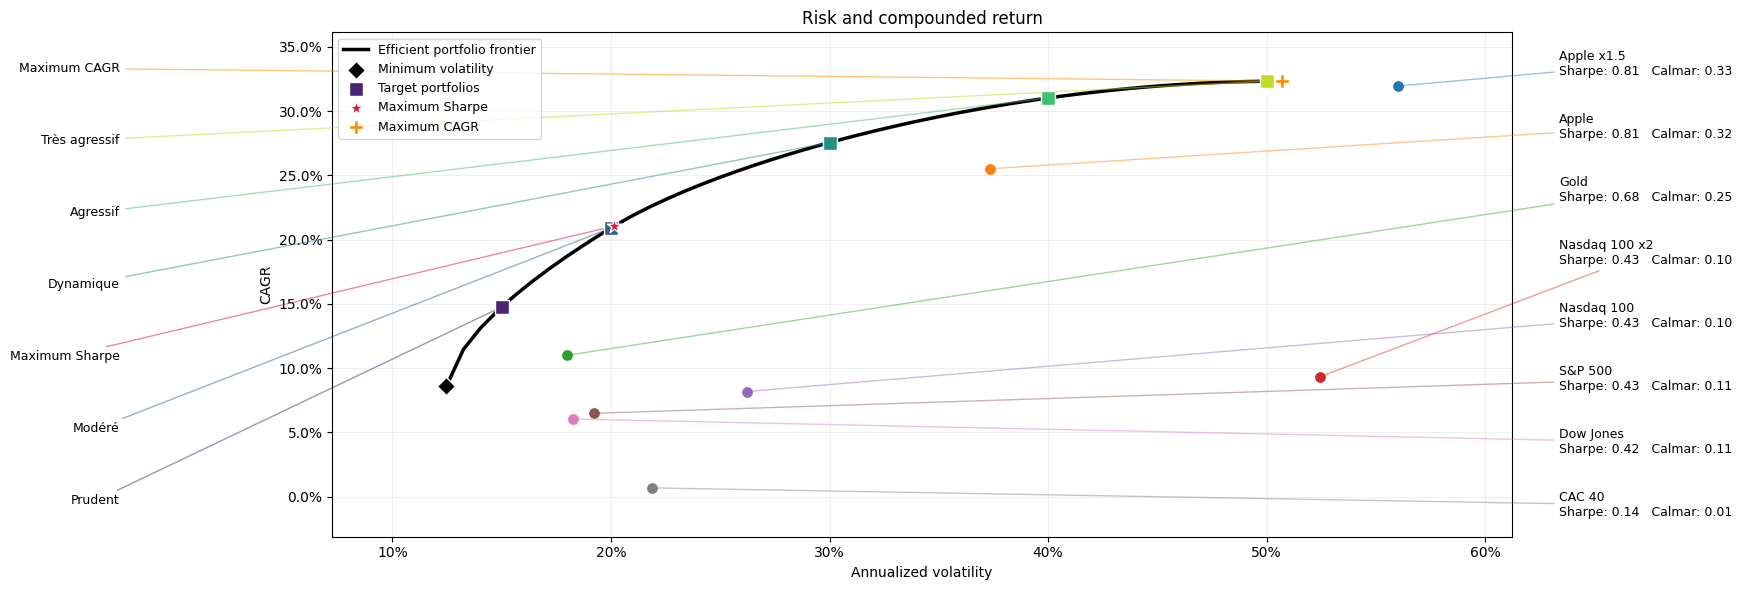

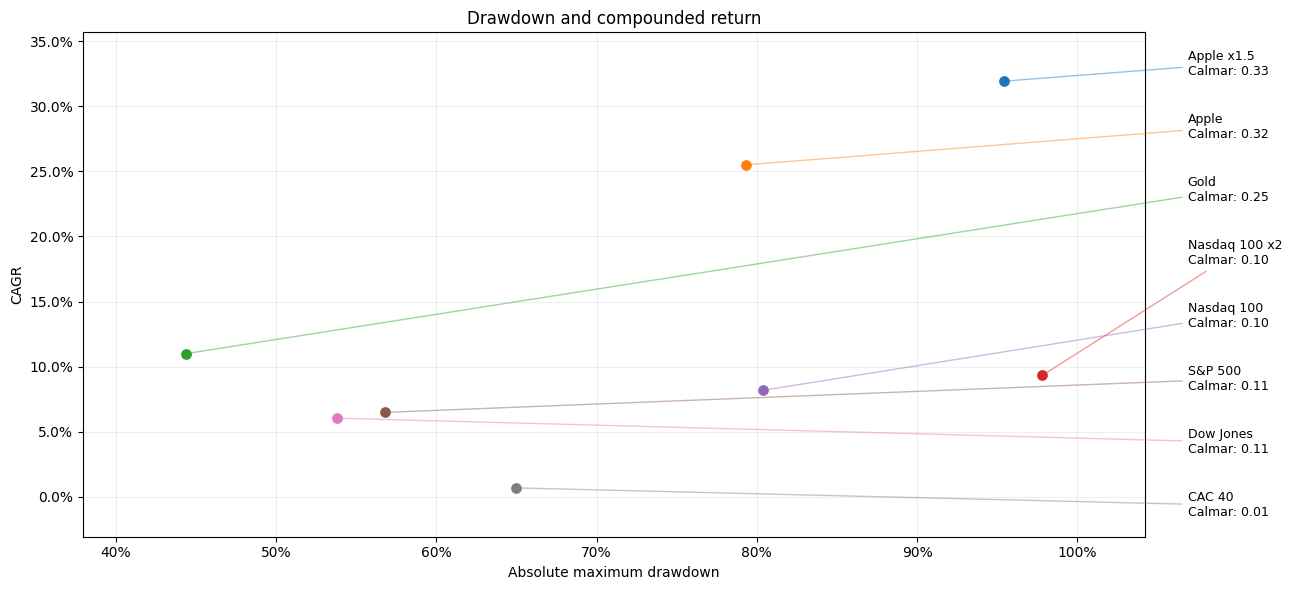

In [8]:
chart_specs = [
    ("Volatility annualized", "Annualized volatility", "Risk and compounded return", True),
    ("Max Drawdown", "Absolute maximum drawdown", "Drawdown and compounded return", False),
]
# Place labels beside the plot, ordered by CAGR, to keep them readable as assets are added.
for metric, xlabel, title, include_sharpe in chart_specs:
    fig, ax = plt.subplots(figsize=(18 if include_sharpe else 13,
        max(6, 0.65 * max(len(stats), len(target_plot_points(target_portfolios)) + 2))))
    ordered_stats = stats.sort_values("CAGR", ascending=False)
    for position, (asset, row) in enumerate(ordered_stats.iterrows()):
        x = abs(row[metric])
        y = row["CAGR"]
        point = ax.scatter(x, y, s=45)
        label = f"{asset}\nCalmar: {row['Calmar']:.2f}"
        if include_sharpe:
            label = f"{asset}\nSharpe: {row['Sharpe']:.2f}   Calmar: {row['Calmar']:.2f}"
        label = label.replace("nan", "—")
        ax.annotate(
            label, xy=(x, y), xytext=(1.04, 1 - (position + 0.5) / len(stats)),
            textcoords="axes fraction", va="center", fontsize=9,
            annotation_clip=False,
            arrowprops={"arrowstyle": "-", "color": point.get_facecolor()[0], "alpha": 0.45},
        )
    if metric == "Volatility annualized":
        # Add exact target solutions to the displayed curve, retaining all 50 frontier samples.
        profile_points = target_plot_points(target_portfolios)
        plotted_frontier = pd.concat([
            efficient_frontier[["Volatility", "CAGR"]],
            pd.DataFrame([(x, y) for _, x, y in profile_points], columns=["Volatility", "CAGR"]),
        ], ignore_index=True).sort_values("Volatility").drop_duplicates()
        ax.plot(
            plotted_frontier["Volatility"], plotted_frontier["CAGR"],
            color="black", linewidth=2.5, zorder=3, label="Efficient portfolio frontier",
        )
        minimum = minimum_volatility_portfolio
        ax.scatter(minimum["Volatility"], minimum["CAGR"], marker="D", s=85,
                   color="black", edgecolors="white", zorder=5, label="Minimum volatility")
        highlights = []
        for position, (profile, x, y) in enumerate(profile_points):
            color = plt.get_cmap("viridis")((position + 0.5) / max(len(profile_points), 1))
            highlights.append({"names": [profile], "x": x, "y": y,
                               "marker": "s", "color": color, "kind": "Target portfolios"})
        # Merge essentially coincident markers and combine their labels.
        for name, portfolio, marker, color in [
            ("Maximum Sharpe", maximum_sharpe_portfolio, "*", "crimson"),
            ("Maximum CAGR", maximum_growth_portfolio, "P", "darkorange"),
        ]:
            x, y = portfolio["Volatility"], portfolio["CAGR"]
            match = next((h for h in highlights if np.allclose(
                [h["x"], h["y"]], [x, y], rtol=0, atol=1e-5)), None)
            if match is not None:
                match["names"].append(name)
                match["marker"] = marker
                match["kind"] += " / " + name
            else:
                highlights.append({"names": [name], "x": x, "y": y,
                                   "marker": marker, "color": color, "kind": name})
        seen_kinds = set()
        for position, h in enumerate(sorted(highlights, key=lambda h: h["y"])):
            label = h["kind"] if h["kind"] not in seen_kinds else "_nolegend_"
            seen_kinds.add(h["kind"])
            ax.scatter(h["x"], h["y"], marker=h["marker"], s=115,
                       color=h["color"], edgecolors="white", zorder=6, label=label)
            # A separate left label column scales with profile count and prevents
            # crowded endpoint/Sharpe labels from obscuring neighboring markers.
            ax.annotate(" / ".join(h["names"]), xy=(h["x"], h["y"]),
                        xytext=(-0.18, (position + 0.5) / len(highlights)),
                        textcoords="axes fraction", ha="right", va="center", fontsize=9,
                        annotation_clip=False,
                        arrowprops={"arrowstyle": "-", "color": h["color"], "alpha": 0.5})
        # Conventional maximum Sharpe is shown at its own CAGR, even if it is
        # slightly below the CAGR-efficient branch.
        ax.legend(loc="upper left", fontsize=9)
    ax.set(xlabel=xlabel, ylabel="CAGR", title=title)
    ax.xaxis.set_major_formatter(PercentFormatter(1.0))
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.margins(0.12)
    ax.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()